In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data = load_wine()
X = data.data
y = data.target

In [9]:
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {data.feature_names}")

Number of samples: 178
Number of features: 13
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [11]:
class_distribution = pd.Series(y).value_counts().sort_index()
class_names = [data.target_names[i] for i in class_distribution.index]

for i, count in enumerate(class_distribution):
    print(f"{class_distribution.index[i]} ({class_names[i]}): {count}")

0 (class_0): 59
1 (class_1): 71
2 (class_2): 48


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X[:5, :5])
print(X_scaled[:5, :5])

[[ 14.23   1.71   2.43  15.6  127.  ]
 [ 13.2    1.78   2.14  11.2  100.  ]
 [ 13.16   2.36   2.67  18.6  101.  ]
 [ 14.37   1.95   2.5   16.8  113.  ]
 [ 13.24   2.59   2.87  21.   118.  ]]
[[ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522]
 [ 0.24628963 -0.49941338 -0.82799632 -2.49084714  0.01814502]
 [ 0.19687903  0.02123125  1.10933436 -0.2687382   0.08835836]
 [ 1.69154964 -0.34681064  0.4879264  -0.80925118  0.93091845]
 [ 0.29570023  0.22769377  1.84040254  0.45194578  1.28198515]]


Standardyzacja jest wymagana przed PCA aby dane z większą skalą (np. 0-10 vs 0-1000) nie miały nieproporcjonalnie wyższej "ważności" przypisanej przez PCA

In [13]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
print("\nWartości własne (eigenvalues):")
for i, ev in enumerate(pca.explained_variance_):
    print(f"  PC{i+1}: {ev:.3f}")

print("\nWyjaśniona wariancja (%):")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.1f}%")

print(f"\nSkumulowana wariancja:")
cumsum = np.cumsum(pca.explained_variance_ratio_)
for i, cs in enumerate(cumsum):
    print(f"  PC1-PC{i+1}: {cs*100:.1f}%")


Wartości własne (eigenvalues):
  PC1: 4.732
  PC2: 2.511
  PC3: 1.454
  PC4: 0.924
  PC5: 0.858
  PC6: 0.645
  PC7: 0.554
  PC8: 0.350
  PC9: 0.291
  PC10: 0.252
  PC11: 0.227
  PC12: 0.170
  PC13: 0.104

Wyjaśniona wariancja (%):
  PC1: 36.2%
  PC2: 19.2%
  PC3: 11.1%
  PC4: 7.1%
  PC5: 6.6%
  PC6: 4.9%
  PC7: 4.2%
  PC8: 2.7%
  PC9: 2.2%
  PC10: 1.9%
  PC11: 1.7%
  PC12: 1.3%
  PC13: 0.8%

Skumulowana wariancja:
  PC1-PC1: 36.2%
  PC1-PC2: 55.4%
  PC1-PC3: 66.5%
  PC1-PC4: 73.6%
  PC1-PC5: 80.2%
  PC1-PC6: 85.1%
  PC1-PC7: 89.3%
  PC1-PC8: 92.0%
  PC1-PC9: 94.2%
  PC1-PC10: 96.2%
  PC1-PC11: 97.9%
  PC1-PC12: 99.2%
  PC1-PC13: 100.0%


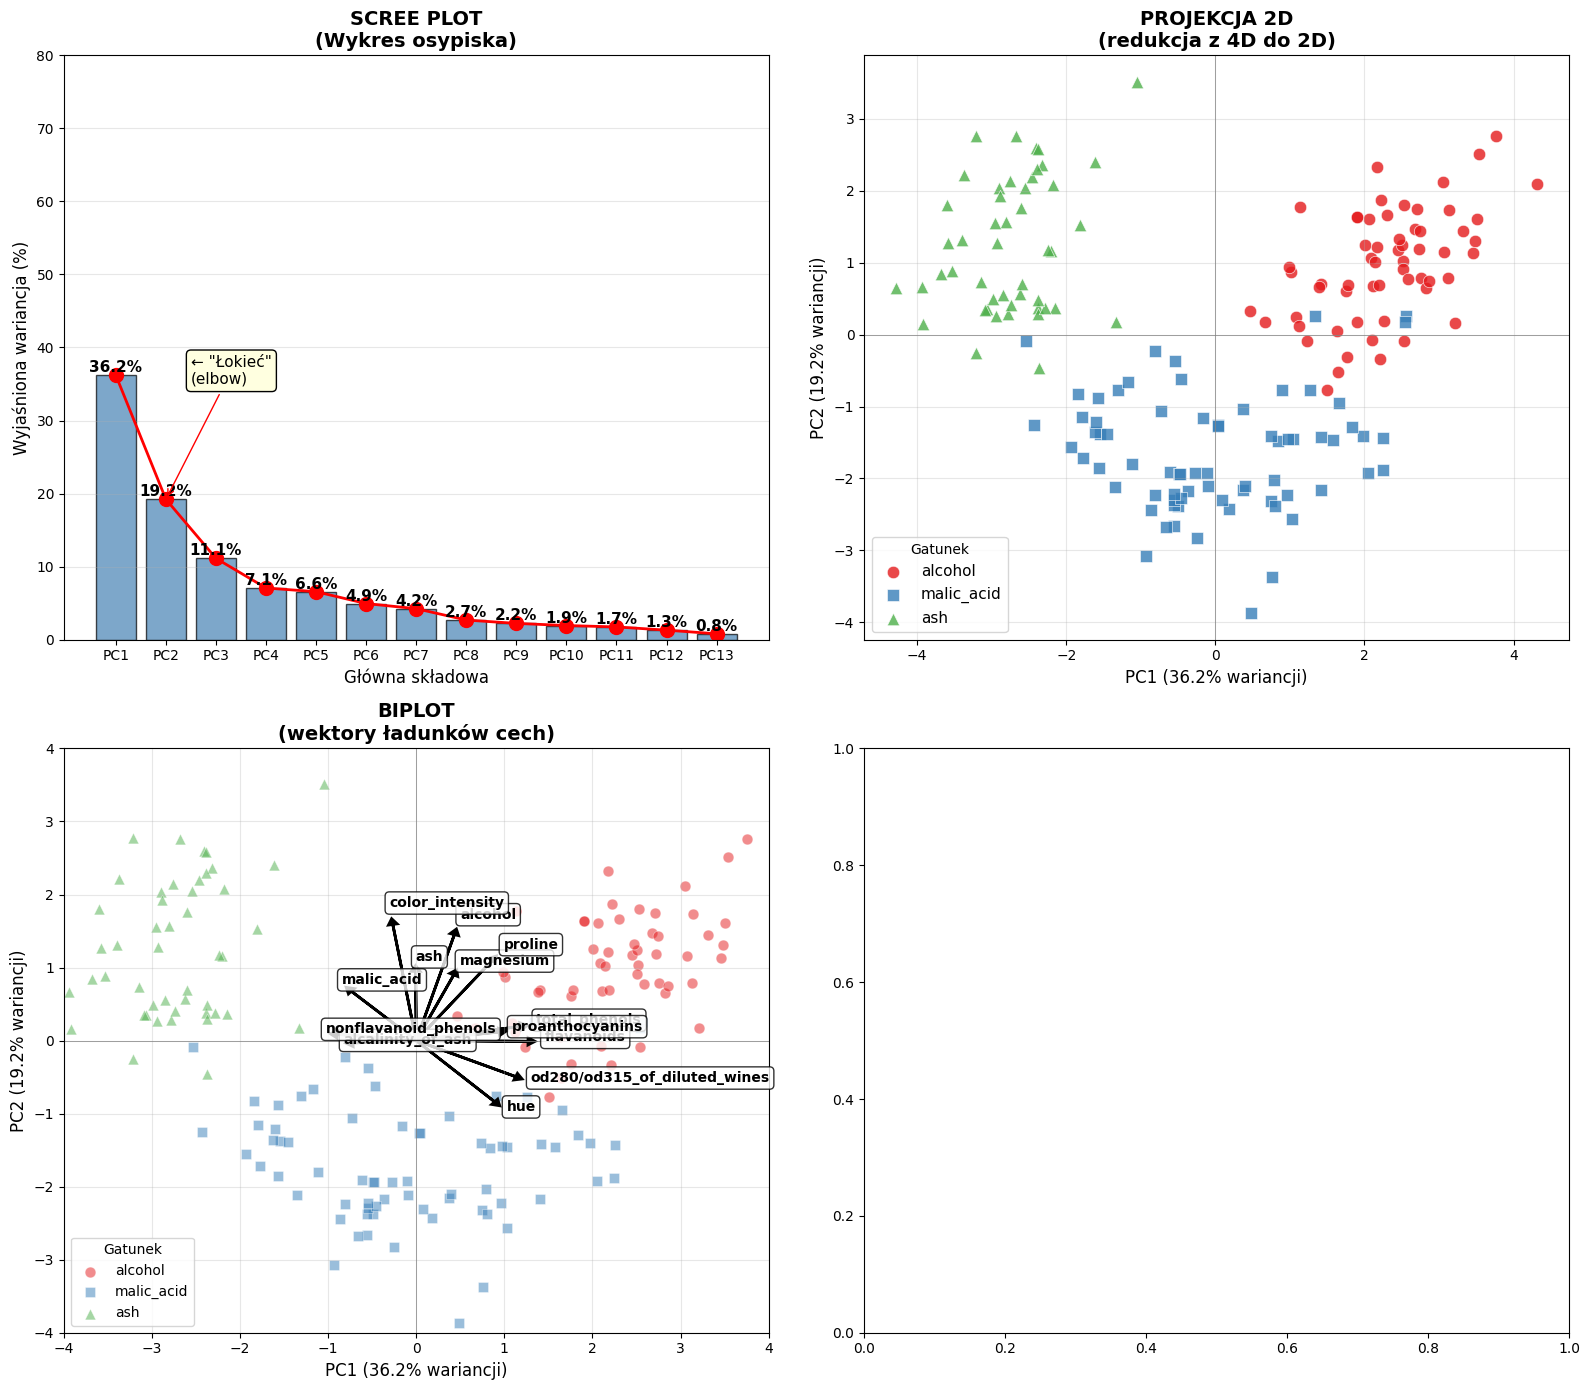

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

ax1 = axes[0, 0]
pc_labels = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13']
variance_pct = pca.explained_variance_ratio_ * 100

bars = ax1.bar(pc_labels, variance_pct, color='steelblue', edgecolor='black', alpha=0.7)
ax1.plot(pc_labels, variance_pct, 'ro-', markersize=10, linewidth=2)
ax1.set_ylabel('Wyjaśniona wariancja (%)', fontsize=12)
ax1.set_xlabel('Główna składowa', fontsize=12)
ax1.set_title('SCREE PLOT\n(Wykres osypiska)', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 80)

for bar, pct in zip(bars, variance_pct):
    ax1.annotate(f'{pct:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.annotate('← "Łokieć"\n(elbow)', xy=(1, variance_pct[1]), xytext=(1.5, 35),
             fontsize=11, arrowprops=dict(arrowstyle='->', color='red'),
             bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax1.grid(axis='y', alpha=0.3)
ax3 = axes[0, 1]
colors = ['#e41a1c', '#377eb8', '#4daf4a']
markers = ['o', 's', '^']

for i, (feature, kolor, marker) in enumerate(zip(data.feature_names, colors, markers)):
    mask = y == i
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=kolor, marker=marker, s=80, label=feature,
                edgecolor='white', linewidth=0.5, alpha=0.8)

ax3.set_xlabel(f'PC1 ({variance_pct[0]:.1f}% wariancji)', fontsize=12)
ax3.set_ylabel(f'PC2 ({variance_pct[1]:.1f}% wariancji)', fontsize=12)
ax3.set_title('PROJEKCJA 2D\n(redukcja z 4D do 2D)', fontsize=14, fontweight='bold')
ax3.legend(title='Gatunek', fontsize=11)
ax3.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax3.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 0]

for i, (feature, kolor, marker) in enumerate(zip(data.feature_names, colors, markers)):
    mask = y == i
    ax4.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=kolor, marker=marker, s=60, label=feature,
                edgecolor='white', linewidth=0.5, alpha=0.5)

scale = 3
for i, feature in enumerate(data.feature_names):
    if i == 3:
        ax4.arrow(0, 0,
              pca.components_[0, i] * scale,
              pca.components_[1, i] * scale,
              head_width=0.1, head_length=0.08, fc='black', ec='black', linewidth=2)
        ax4.text(pca.components_[0, i] * scale * 1.15,
             pca.components_[1, i] * scale * 1.65,
             feature, fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        ax4.arrow(0, 0,
              pca.components_[0, i] * scale,
              pca.components_[1, i] * scale,
              head_width=0.1, head_length=0.08, fc='black', ec='black', linewidth=2)
        ax4.text(pca.components_[0, i] * scale * 1.15,
             pca.components_[1, i] * scale * 1.15,
             feature, fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


ax4.set_xlabel(f'PC1 ({variance_pct[0]:.1f}% wariancji)', fontsize=12)
ax4.set_ylabel(f'PC2 ({variance_pct[1]:.1f}% wariancji)', fontsize=12)
ax4.set_title('BIPLOT\n(wektory ładunków cech)', fontsize=14, fontweight='bold')
ax4.legend(title='Gatunek', fontsize=10, loc='lower left')
ax4.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax4.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax4.set_xlim(-4, 4)
ax4.set_ylim(-4, 4)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_iris_demo.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
print(f"{'Cecha':<20} {'PC1':>8} {'PC2':>8}")
for i, feature in enumerate(data.feature_names):
    loadings = pca.components_[:, i]
    print(f"{feature:<20} {loadings[0]:>8.3f} {loadings[1]:>8.3f}")

Cecha                     PC1      PC2
alcohol                 0.144    0.484
malic_acid             -0.245    0.225
ash                    -0.002    0.316
alcalinity_of_ash      -0.239   -0.011
magnesium               0.142    0.300
total_phenols           0.395    0.065
flavanoids              0.423   -0.003
nonflavanoid_phenols   -0.299    0.029
proanthocyanins         0.313    0.039
color_intensity        -0.089    0.530
hue                     0.297   -0.279
od280/od315_of_diluted_wines    0.376   -0.164
proline                 0.287    0.365


W PC1 dominuje flavanoids, czyli rodzaj felonoli.
W PC2 dominuje color_intensity
